In [5]:
#install pandas
%pip install pandas
#install numpy
%pip install numpy
#install matplotlib
%pip install matplotlib
#install seaborn
%pip install seaborn
#install requests
%pip install requests
#install tqdm
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


  Using cached requests-2.32.5-py3-none-any.whl (64 kB)
  Using cached certifi-2025.10.5-py3-none-any.whl (163 kB)
  Using cached idna-3.11-py3-none-any.whl (71 kB)
  Using cached charset_normalizer-3.4.4-cp310-cp310-win_amd64.whl (107 kB)



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------------------------------- 78.5/78.5 kB 484.4 kB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x


c:\Users\rodri\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Importar reports diarios de 2020 a 2021 (descarga concurrente, con reintentos)
start = datetime(2020, 1, 1)
end = datetime(2021, 12, 31)
dates = []
d = start
while d <= end:
    dates.append(d)
    d += timedelta(days=1)

base_raw = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/"

# Configurar sesión con reintentos
session = requests.Session()
retries = Retry(total=3, backoff_factor=0.5, status_forcelist=[429,500,502,503,504])
session.mount("https://", HTTPAdapter(max_retries=retries))

def fetch_report(date_obj, session=session, timeout=10):
    url = base_raw + date_obj.strftime("%m-%d-%Y") + ".csv"
    try:
        resp = session.get(url, timeout=timeout)
        if resp.status_code == 200 and resp.text.strip():
            df = pd.read_csv(StringIO(resp.text))
            df['report_date'] = date_obj.date()
            return (date_obj.strftime("%Y-%m-%d"), df, None)
        else:
            return (date_obj.strftime("%Y-%m-%d"), None, f"HTTP {resp.status_code}")
    except Exception as e:
        return (date_obj.strftime("%Y-%m-%d"), None, str(e))

df_list = []
missing = []

# Ajusta workers según tu conexión/CPU; 8 es razonable en local
max_workers = 8
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(fetch_report, dt): dt for dt in dates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Descargando"):
        date_str = None
        try:
            date_str, df_day, err = fut.result()
            if df_day is not None:
                df_list.append(df_day)
            else:
                missing.append((date_str, err))
        except Exception as e:
            # Guardar excepción si algo inesperado sucede en el worker
            missing.append((str(futures[fut].date()), str(e)))

# Concatenar una vez completadas las descargas
if df_list:
    df = pd.concat(df_list, ignore_index=True)
else:
    df = pd.DataFrame()

print(f"Archivos leídos: {len(df_list)}, faltantes: {len(missing)}")
if missing:
    print("Ejemplos de faltantes:", missing[:10])

Descargando: 100%|██████████| 731/731 [01:22<00:00,  8.88it/s]


Archivos leídos: 710, faltantes: 21
Ejemplos de faltantes: [('2020-01-04', 'HTTP 404'), ('2020-01-07', 'HTTP 404'), ('2020-01-03', 'HTTP 404'), ('2020-01-08', 'HTTP 404'), ('2020-01-05', 'HTTP 404'), ('2020-01-01', 'HTTP 404'), ('2020-01-02', 'HTTP 404'), ('2020-01-06', 'HTTP 404'), ('2020-01-09', 'HTTP 404'), ('2020-01-10', 'HTTP 404')]


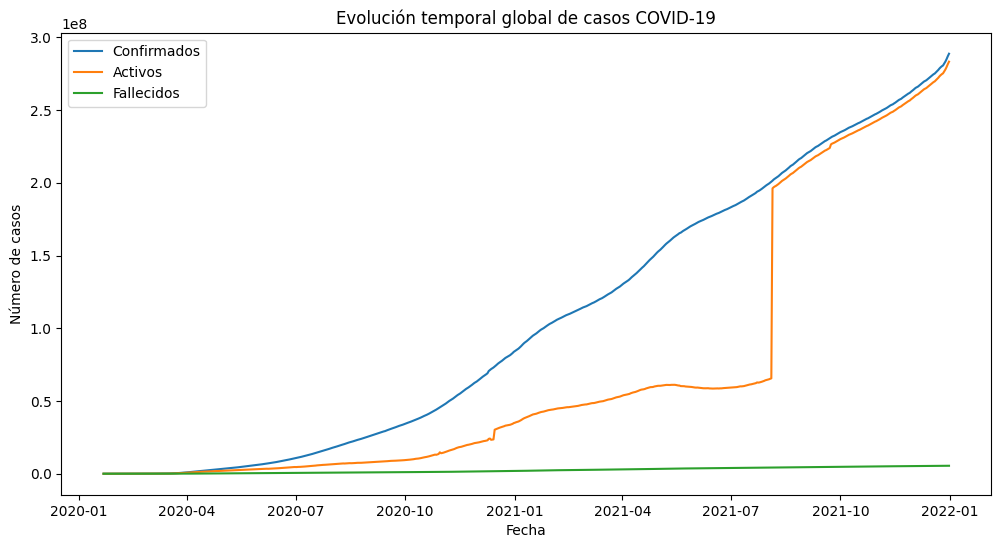

In [ ]:
#1. Evolución temporal global de casos confirmados, activos y fallecidos (líneas). 
df['Confirmed'] = pd.to_numeric(df['Confirmed'], errors='coerce').fillna(0)
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce').fillna(0)
df['Recovered'] = pd.to_numeric(df['Recovered'], errors='coerce').fillna(0)
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']
time_series = df.groupby('report_date').agg({'Confirmed':'sum', 'Active':'sum', 'Deaths':'sum'}).reset_index()
plt.figure(figsize=(12,6))
plt.plot(time_series['report_date'], time_series['Confirmed'], label='Confirmados')
plt.plot(time_series['report_date'], time_series['Active'], label='Activos')
plt.plot(time_series['report_date'], time_series['Deaths'], label='Fallecidos')
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.title('Evolución temporal global de casos COVID-19')
plt.legend()
plt.show()

C:\Users\rodri\AppData\Local\Temp\ipykernel_15292\351097744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_countries, x='Confirmed', y='Country_Region', palette='viridis')


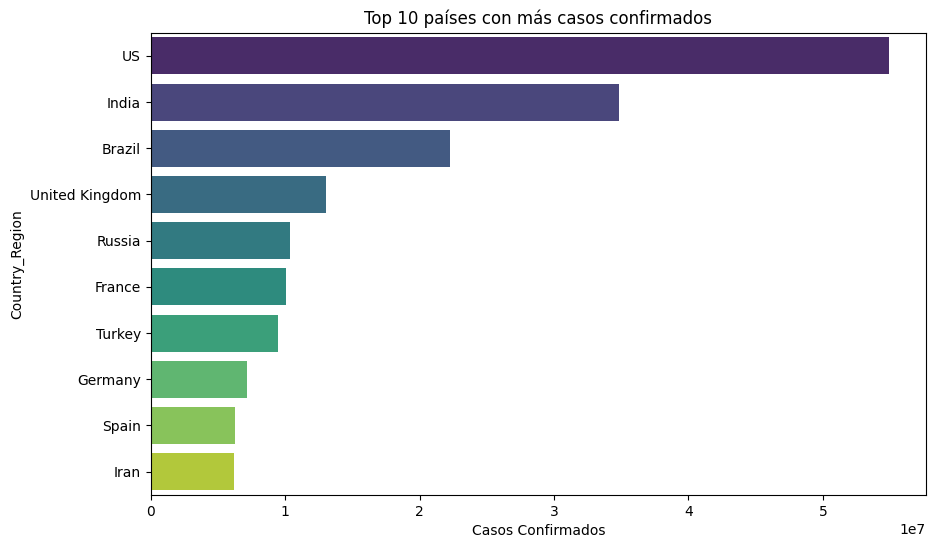

In [9]:

#2. Comparativa Top 10 países con más casos confirmados (barras). 
latest_date = df['report_date'].max()
latest_data = df[df['report_date'] == latest_date] 
top10_countries = latest_data.groupby('Country_Region')['Confirmed'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top10_countries, x='Confirmed', y='Country_Region', palette='viridis')
plt.xlabel('Casos Confirmados')
plt.title('Top 10 países con más casos confirmados')
plt.show()